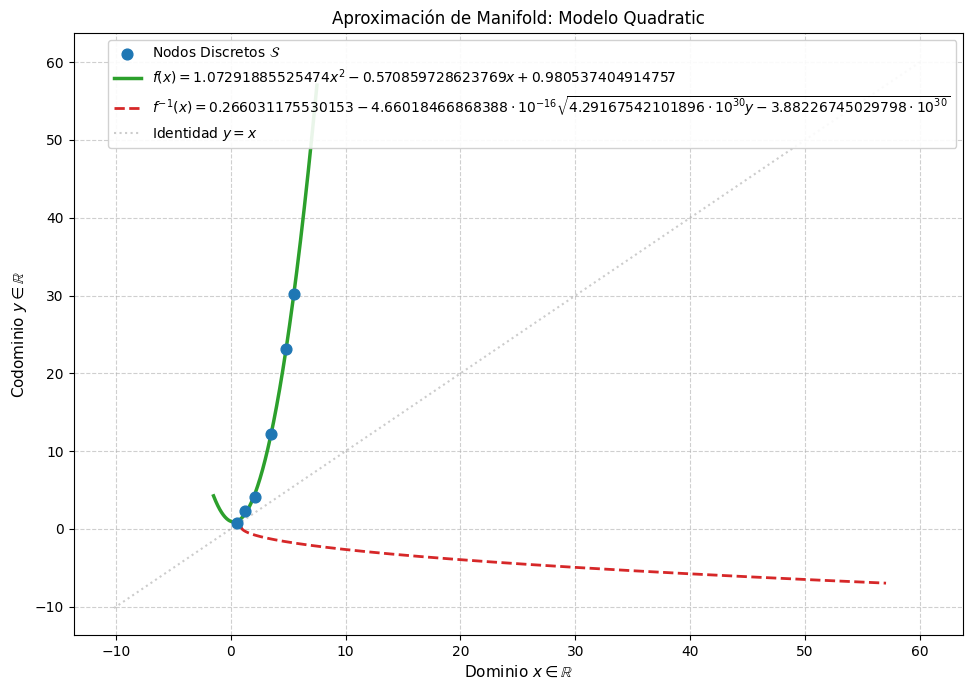

Expresión Primal f(x): 1.07291885525474*x**2 - 0.570859728623769*x + 0.980537404914757
Expresión Dual Inversa f^-1(y): 0.266031175530153 - 4.66018466868388e-16*sqrt(4.29167542101896e+30*y - 3.88226745029798e+30)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import curve_fit

class FunctionalSpaceFitter:
    """
    Abstracción matemática para el ajuste, representación y cálculo de inversas
    de manifolds funcionales unidimensionales sobre un espacio L2.
    """
    def __init__(self, x_data, y_data):
        self.x_data = np.array(x_data, dtype=np.float64)
        self.y_data = np.array(y_data, dtype=np.float64)
        self.x_sym = sp.Symbol('x', real=True)
        self.y_sym = sp.Symbol('y', real=True)

    # Base axiomática de familias funcionales
    @staticmethod
    def _linear(x, a, b):
        return a * x + b

    @staticmethod
    def _quadratic(x, a, b, c):
        return a * x**2 + b * x + c

    @staticmethod
    def _exponential(x, a, b, c):
        return a * np.exp(b * x) + c

    @staticmethod
    def _logarithmic(x, a, b, c, d):
        return a * np.log(np.clip(b * x + c, 1e-12, None)) + d

    @staticmethod
    def _trigonometric(x, a, b, c, d):
        return a * np.sin(b * x + c) + d

    @staticmethod
    def _hyperbolic(x, a, b, c, d):
        return a * np.tanh(b * x + c) + d

    @staticmethod
    def _rational_hyperbola(x, a, b, c):
        return a / (x - b + 1e-9) + c

    def fit_and_render(self, model_type='quadratic', poly_degree=3, calculate_inverse=True):
        """
        Ejecuta la optimización paramétrica en la variedad especificada,
        deriva la forma simbólica via SymPy y computa la función inversa si existe.
        """
        x_dense = np.linspace(min(self.x_data) - 2, max(self.x_data) + 2, 1000)
        sym_expr = None
        y_fit_dense = None

        # Optimization & Symbolic Mapping Routing
        if model_type == 'linear':
            popt, _ = curve_fit(self._linear, self.x_data, self.y_data)
            y_fit_dense = self._linear(x_dense, *popt)
            sym_expr = popt[0] * self.x_sym + popt[1]

        elif model_type == 'quadratic':
            popt, _ = curve_fit(self._quadratic, self.x_data, self.y_data)
            y_fit_dense = self._quadratic(x_dense, *popt)
            sym_expr = popt[0] * self.x_sym**2 + popt[1] * self.x_sym + popt[2]

        elif model_type == 'polynomial':
            coeffs = np.polyfit(self.x_data, self.y_data, deg=poly_degree)
            poly_func = np.poly1d(coeffs)
            y_fit_dense = poly_func(x_dense)
            sym_expr = sum(c * self.x_sym**(poly_degree - i) for i, c in enumerate(coeffs))

        elif model_type == 'exponential':
            popt, _ = curve_fit(self._exponential, self.x_data, self.y_data, p0=[1, 0.1, 0], maxfev=10000)
            y_fit_dense = self._exponential(x_dense, *popt)
            sym_expr = popt[0] * sp.exp(popt[1] * self.x_sym) + popt[2]

        elif model_type == 'logarithmic':
            popt, _ = curve_fit(self._logarithmic, self.x_data, self.y_data, p0=[1, 1, 1, 0], maxfev=10000)
            y_fit_dense = self._logarithmic(x_dense, *popt)
            sym_expr = popt[0] * sp.log(popt[1] * self.x_sym + popt[2]) + popt[3]

        elif model_type == 'trigonometric':
            popt, _ = curve_fit(self._trigonometric, self.x_data, self.y_data, p0=[1, 1, 0, 0], maxfev=10000)
            y_fit_dense = self._trigonometric(x_dense, *popt)
            sym_expr = popt[0] * sp.sin(popt[1] * self.x_sym + popt[2]) + popt[3]

        elif model_type == 'hyperbolic':
            popt, _ = curve_fit(self._hyperbolic, self.x_data, self.y_data, p0=[1, 1, 0, 0], maxfev=10000)
            y_fit_dense = self._hyperbolic(x_dense, *popt)
            sym_expr = popt[0] * sp.tanh(popt[1] * self.x_sym + popt[2]) + popt[3]

        elif model_type == 'hyperbola_rational':
            popt, _ = curve_fit(self._rational_hyperbola, self.x_data, self.y_data, p0=[1, 0, 0], maxfev=10000)
            y_fit_dense = self._rational_hyperbola(x_dense, *popt)
            sym_expr = popt[0] / (self.x_sym - popt[1]) + popt[2]

        else:
            raise ValueError(f"Variedad funcional '{model_type}' no tipificada en el dominio.")

        # Tratamiento Hermenéutico del Cómputo Inverso Symbolico
        inverse_sym = None
        if calculate_inverse and sym_expr is not None:
            try:
                # Inversión analítica mediante resolución del morfismo y = f(x) -> x = f^-1(y)
                equation = sp.Eq(self.y_sym, sym_expr)
                solutions = sp.solve(equation, self.x_sym)
                if solutions:
                    inverse_sym = solutions[0] # Selección de la rama funcional directa
            except Exception as e:
                print(f"[Advertencia Epistemológica]: Inversión simbólica no convergente en forma cerrada: {e}")

        # Visualización Cartesiana e Isomorfismo Gráfico
        fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
        ax.style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default'

        # Puntos experimentales discreto
        ax.scatter(self.x_data, self.y_data, color='#1f77b4', s=60, zorder=5, label=r'Nodos Discretos $\mathcal{S}$')

        # Función Primaria f(x)
        ax.plot(x_dense, y_fit_dense, color='#2ca02c', linewidth=2.5, label=f'$f(x) = {sp.latex(sp.simplify(sym_expr))}$')

        # Renderizado de Inversa f^-1(x) si la biyección existe en forma explicitable
        if inverse_sym is not None:
            try:
                inv_func = sp.lambdify(self.y_sym, inverse_sym, modules=['numpy', 'scipy'])
                y_dense_inv = np.linspace(min(y_fit_dense), max(y_fit_dense), 1000)
                x_fit_inv = inv_func(y_dense_inv)

                # Graficamos la inversa en el plano x-y estándar $f^-1(x)$
                ax.plot(y_dense_inv, x_fit_inv, color='#d62728', linestyle='--', linewidth=2,
                        label=f'$f^{{-1}}(x) = {sp.latex(sp.simplify(inverse_sym))}$')
            except Exception:
                # Alternativa de proyección espectral simétrica sobre el eje diagonal identity \Delta
                ax.plot(y_fit_dense, x_dense, color='#d62728', linestyle='--', linewidth=1.5,
                        label=r'Inversa Implícita (Reflexión en $y=x$)')

        # Eje de Simetría Especular (Línea de Identidad)
        lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
        ax.plot(lims, lims, color='gray', alpha=0.4, linestyle=':', label=r'Identidad $y = x$')

        ax.set_title(f'Aproximación de Manifold: Modelo {model_type.capitalize()}', fontsize=12)
        ax.set_xlabel(r'Dominio $x \in \mathbb{R}$', fontsize=11)
        ax.set_ylabel(r'Codominio $y \in \mathbb{R}$', fontsize=11)
        ax.legend(loc='best', frameon=True, facecolor='white', framealpha=0.9)
        ax.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()

        return sym_expr, inverse_sym


# ==========================================
# EJECUCIÓN DEL OPERADOR SOBRE UN CONJUNTO N
# ==========================================
# Nodos muestrales x_i, y_i
X = [0.5, 1.2, 2.1, 3.5, 4.8, 5.5]
Y = [0.8, 2.3, 4.1, 12.2, 23.1, 30.2]

fitter = FunctionalSpaceFitter(X, Y)

# Modelos disponibles: 'linear', 'quadratic',
# 'exponential', 'logarithmic', 'trigonometric', 'hyperbolic', 'hyperbola_rational'
f_x, f_inv = fitter.fit_and_render(model_type='quadratic')

print(f"Expresión Primal f(x): {f_x}")
print(f"Expresión Dual Inversa f^-1(y): {f_inv}")